In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def read_file(filename):
    return pd.read_csv(filename)

df_raw = read_file("result.csv")


In [3]:
# Group by threads, outside_work, n and compute average of tas_ms, ttas_ms, mcs_ms
grouped_avg = df_raw.groupby(['threads', 'outside_work', 'n', 'use_backoff']).agg(
    avg_tas_ms=('tas_ms', 'mean'),
    avg_ttas_ms=('ttas_ms', 'mean'),
    avg_mcs_ms=('mcs_ms', 'mean')
).reset_index()

# To view the first few rows of the result
# display(grouped_avg)
grouped_avg.rename(columns={'avg_tas_ms': 'tas_ms', 'avg_ttas_ms': 'ttas_ms', 'avg_mcs_ms': 'mcs_ms'}, inplace=True)
grouped_avg.head()

,threads,outside_work,n,use_backoff,tas_ms,ttas_ms,mcs_ms
0,1,0,53,0,0.862000,0.706840,0.641270
1,1,0,53,1,0.589300,0.614200,-1.000000
2,1,0,89,0,0.606390,0.544195,0.525305
3,1,0,89,1,0.473200,0.359000,-1.000000
4,1,0,101,0,0.429375,0.477860,0.477020


In [4]:
df_with_exponential_backoff = grouped_avg[grouped_avg["use_backoff"] == 1]
df = grouped_avg[grouped_avg["use_backoff"] == 0]

In [5]:
df.describe()

,threads,outside_work,n,use_backoff,tas_ms,ttas_ms,mcs_ms
count,336.000000,336.000000,336.00000,336.0,336.000000,336.000000,336.000000
mean,9.000000,4.166667,20223.25000,0.0,602.915521,659.862232,648.331211
std,6.750124,3.188911,34205.53937,0.0,1292.232953,1479.421373,1430.218388
min,1.000000,0.000000,53.00000,0.0,0.373405,0.345800,0.326380
25%,2.000000,1.000000,98.00000,0.0,4.599364,4.383011,4.660043
50%,8.000000,4.000000,756.00000,0.0,22.133850,20.520430,20.574877
75%,16.000000,7.000000,20010.50000,0.0,469.531187,470.284175,481.387588
max,20.000000,9.000000,100003.00000,0.0,7321.810500,8371.688000,7713.527500


In [6]:
# df_10000 = df #df[df['n'] == 100]
# df_10000.describe()

In [7]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.scatter(df_10000['threads'], df_10000['tas_ms'])
# plt.title('Scatter Plot of Threads vs tas_ms (n = 10000)')
# plt.xlabel('Threads')
# plt.ylabel('tas_ms')
# plt.grid(True)
# plt.show()

In [8]:
# # Plot Time vs Threads for each lock type, with separate curves for each outside_work

# import seaborn as sns

# locks = ['tas_ms', 'ttas_ms', 'mcs_ms']
# lock_names = {'tas_ms': 'Test-and-Set', 'ttas_ms': 'Test-and-Test-and-Set', 'mcs_ms': 'MCS'}
# outside_works = sorted(df_10000['outside_work'].unique())

# for lock in locks:
#     plt.figure(figsize=(10,6))
#     for out in outside_works:
#         df_group = df_10000[df_10000['outside_work'] == out]
#         # Sort by threads for clearer lines
#         df_group = df_group.sort_values('threads')
#         plt.plot(df_group['threads'], df_group[lock], marker='o', label=f'OUTSIDE_WORK={out}')
#     plt.title(f'Time vs Threads for {lock_names[lock]} Lock\n(n = 10000)')
#     plt.xlabel('Threads')
#     plt.ylabel('Time (ms)')
#     plt.legend(title='OUTSIDE_WORK')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

### Analyze PERFORMANCE among locking mechanism

#### Heat map on average execution time

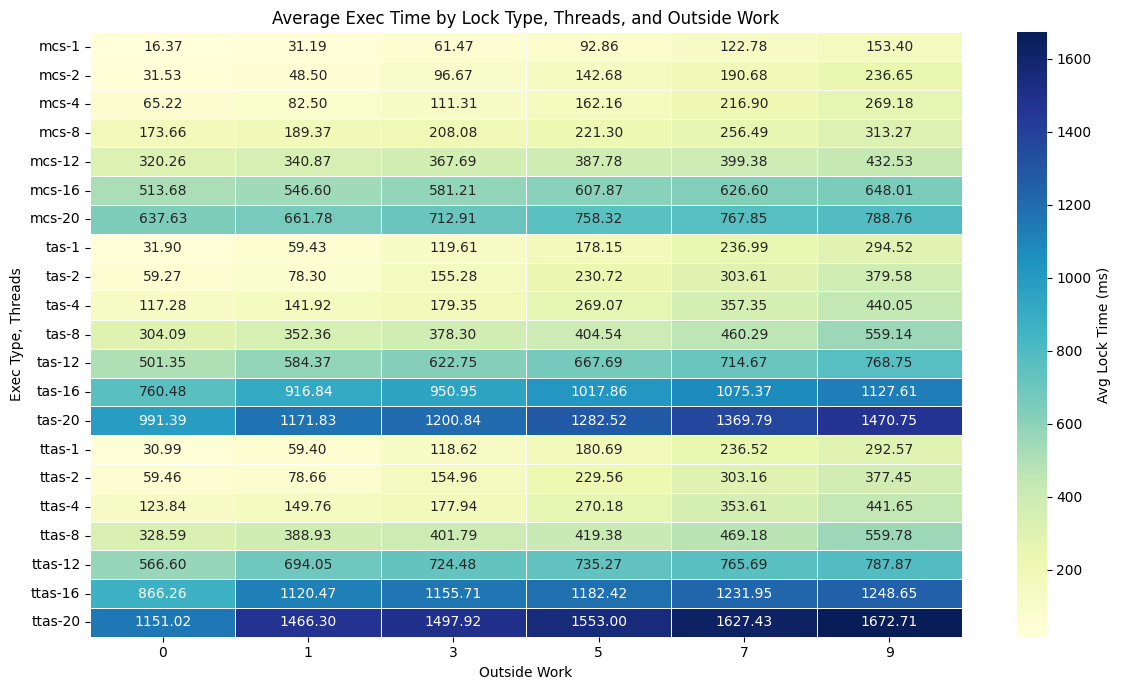

In [9]:
# Prepare 'lock', 'time' format for easier analysis, then concatenate for all lock types
frames = []
for lock in ['tas_ms', 'ttas_ms', 'mcs_ms']:
    df_tmp = grouped_avg[['threads', 'n', 'outside_work', lock]].copy()
    df_tmp = df_tmp.rename(columns={lock: 'time'})
    df_tmp['lock'] = lock.replace('_ms', '')
    frames.append(df_tmp)

df_long = pd.concat(frames, ignore_index=True)

# Calculate min, median, max, avg by lock and threads (for small contention)
min_time = df_long.groupby(['lock', 'threads'])['time'].min()
median_time = df_long.groupby(['lock', 'threads'])['time'].median()
max_time = df_long.groupby(['lock', 'threads'])['time'].max()
avg_time = df_long.groupby(['lock', 'threads'])['time'].mean()

# Present as DataFrame for easier inspection:
stats_df = pd.DataFrame({
    'min': min_time,
    'median': median_time,
    'max': max_time,
    'avg': avg_time
}).reset_index()

# display(stats_df)

# Create a pivot table: rows=(lock,threads), columns=outside_work, values=time (avg)
pivot_table = pd.pivot_table(
    df_long, 
    values='time',
    index=['lock', 'threads'],
    columns=['outside_work'],
    aggfunc='mean'
)

# show chart

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=.5, 
    cbar_kws={'label': 'Avg Lock Time (ms)'}
)
plt.title('Average Exec Time by Lock Type, Threads, and Outside Work')
plt.ylabel('Exec Type, Threads')
plt.xlabel('Outside Work')
plt.tight_layout()
plt.show()




In [10]:
df[df.threads == 12][df.outside_work == 1]

# TAS take

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\77580996.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df.threads == 12][df.outside_work == 1]


,threads,outside_work,n,use_backoff,tas_ms,ttas_ms,mcs_ms
400,12,1,53,0,5.451100,5.667425,4.803410
402,12,1,89,0,7.067650,7.129085,6.114620
404,12,1,101,0,7.494165,7.584705,6.231025
406,12,1,503,0,23.807135,22.348550,21.046510
408,12,1,1009,0,43.450710,42.748660,37.067440
410,12,1,10007,0,365.702100,355.139700,334.828750
412,12,1,50021,0,1589.565500,1741.280500,1674.699500
414,12,1,100003,0,3104.231500,3622.088000,3377.183000


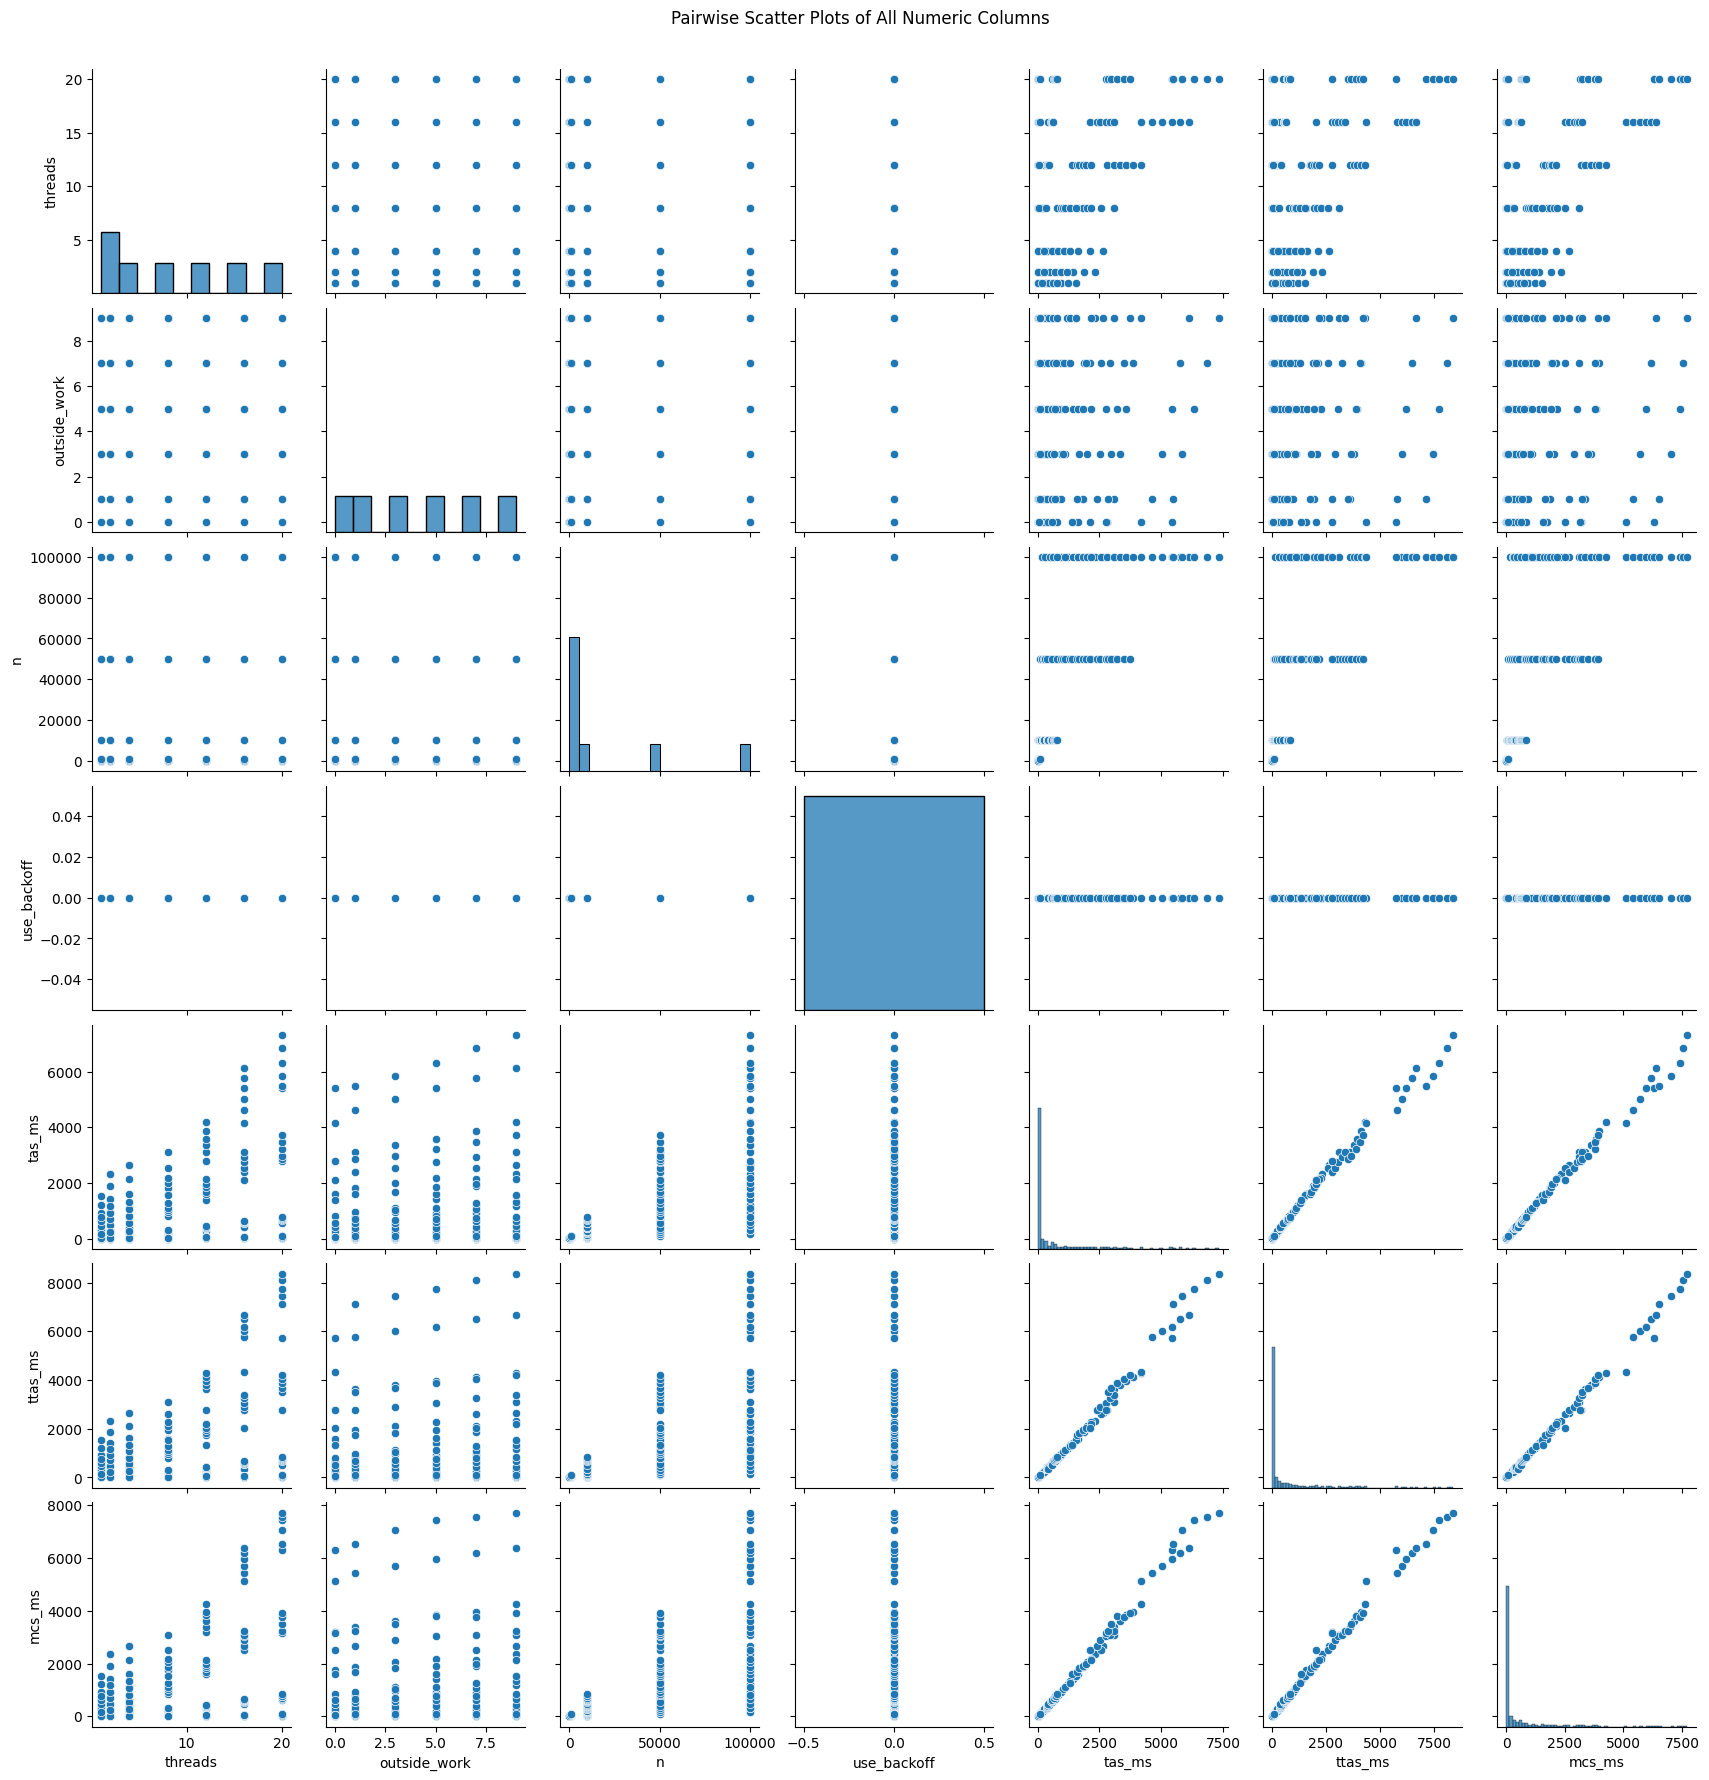

In [11]:
# Scatter plot all numeric columns against each other (pairplot)
import seaborn as sns
import matplotlib.pyplot as plt

# Only numeric columns
numeric_cols = df.select_dtypes(include='number')

sns.pairplot(numeric_cols)
plt.suptitle("Pairwise Scatter Plots of All Numeric Columns", y=1.02)
plt.show()

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\310345389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_outside'] = df['threads'].astype(str) + '_' + df['outside_work'].astype(str)
C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\310345389.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_outside_code'] = LabelEncoder().fit_transform(df['threads_outside'])


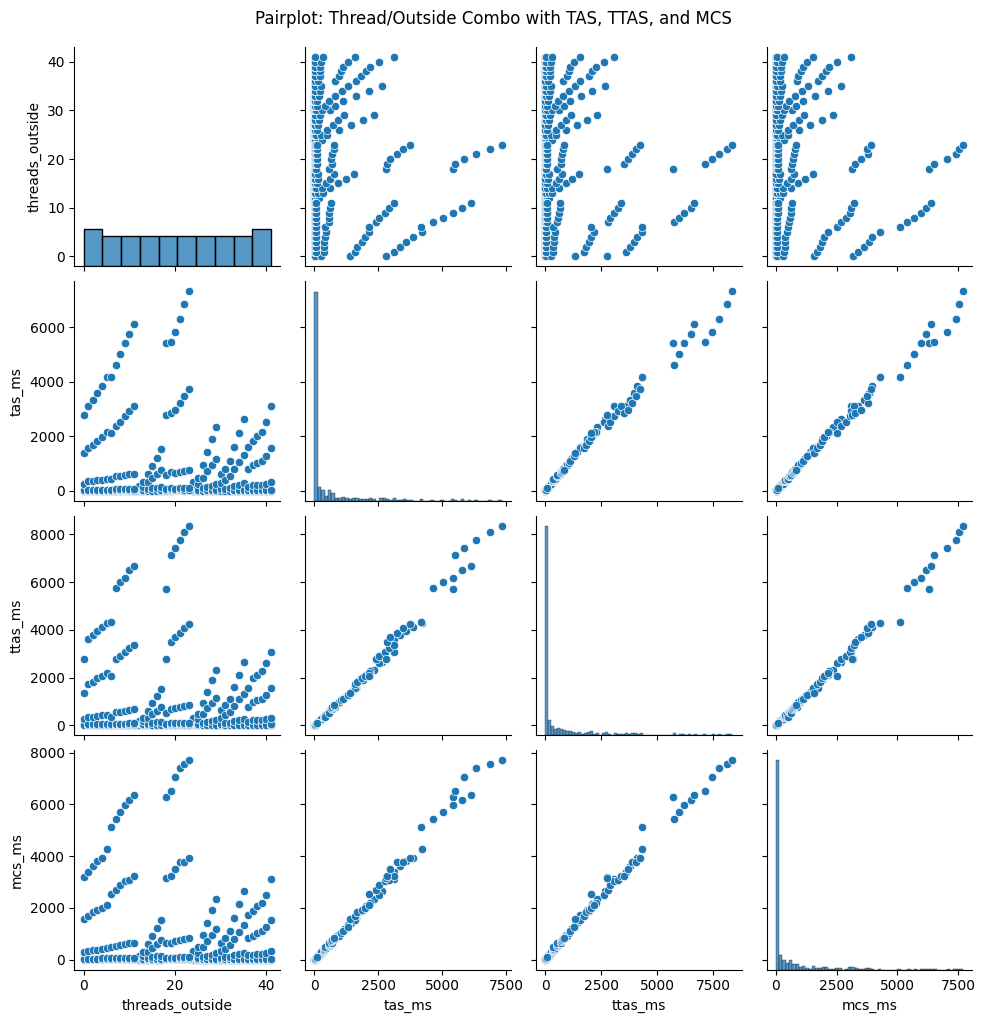

In [12]:
# Create a new column combining thread and outside work
df['threads_outside'] = df['threads'].astype(str) + '_' + df['outside_work'].astype(str)

# Prepare dataframe for pairplot
pairplot_cols = ['threads_outside', 'tas_ms', 'ttas_ms', 'mcs_ms']

# Since pairplot works best with numeric columns, let's encode 'threads_outside'
from sklearn.preprocessing import LabelEncoder
df['threads_outside_code'] = LabelEncoder().fit_transform(df['threads_outside'])
pairplot_data = df[['threads_outside_code', 'tas_ms', 'ttas_ms', 'mcs_ms']]
pairplot_data = pairplot_data.rename(columns={'threads_outside_code': 'threads_outside'})  # For readable plot

sns.pairplot(pairplot_data)
plt.suptitle("Pairplot: Thread/Outside Combo with TAS, TTAS, and MCS", y=1.02)
plt.show()

# not very clear

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\2067444304.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_n'] = df['threads'].astype(str) + '_' + df['n'].astype(str)
C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\2067444304.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_n_code'] = LabelEncoder().fit_transform(df['threads_n'])


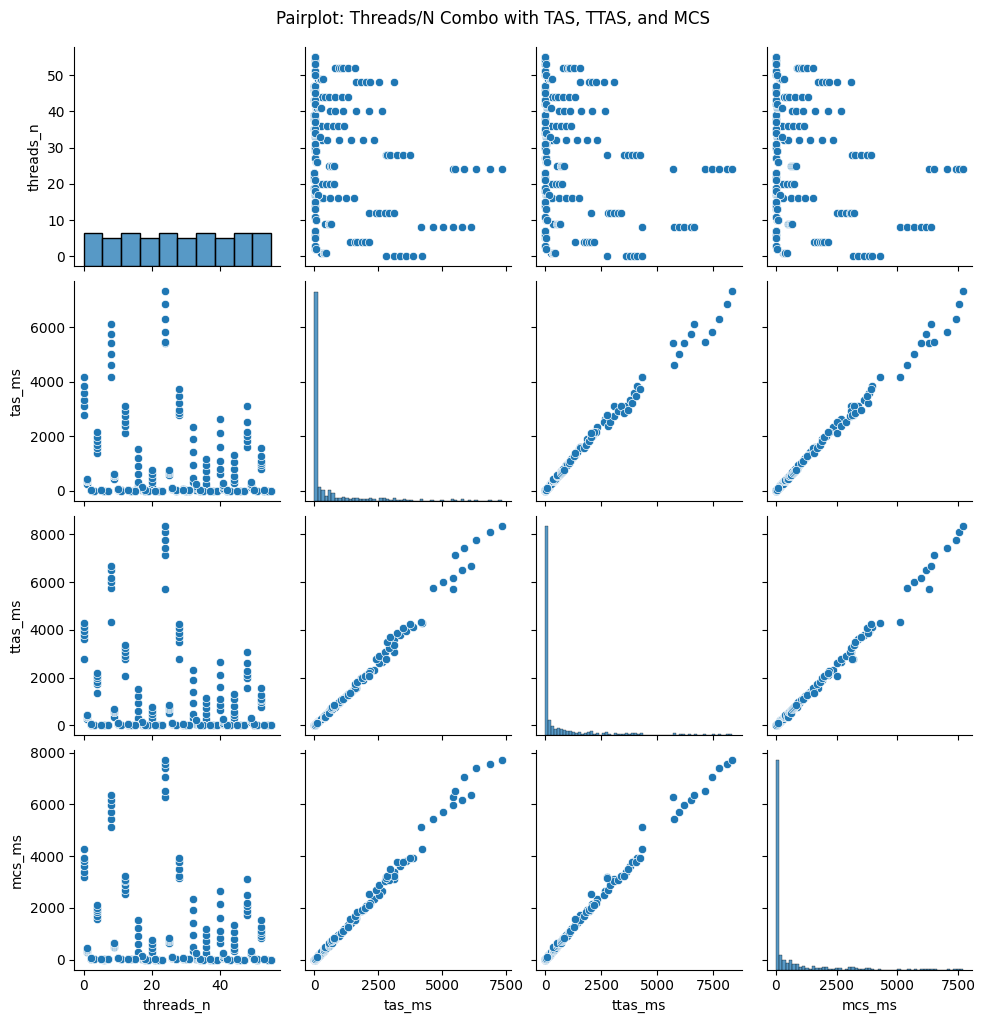

In [13]:
# Pairplot of thread and n, with mcs, ttas, tas

# Create a new column combining threads and n
df['threads_n'] = df['threads'].astype(str) + '_' + df['n'].astype(str)

# Encode 'threads_n' for use in pairplot as a pseudo-categorical variable
df['threads_n_code'] = LabelEncoder().fit_transform(df['threads_n'])

# Prepare dataframe for pairplot
pairplot_cols_threads_n = ['threads_n_code', 'tas_ms', 'ttas_ms', 'mcs_ms']
pairplot_data_threads_n = df[pairplot_cols_threads_n]
pairplot_data_threads_n = pairplot_data_threads_n.rename(columns={'threads_n_code': 'threads_n'})

sns.pairplot(pairplot_data_threads_n)
plt.suptitle("Pairplot: Threads/N Combo with TAS, TTAS, and MCS", y=1.02)
plt.show()

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\678295518.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['outside_n'] = df['outside_work'].astype(str) + '_' + df['n'].astype(str)
C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\678295518.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['outside_n_code'] = LabelEncoder().fit_transform(df['outside_n'])


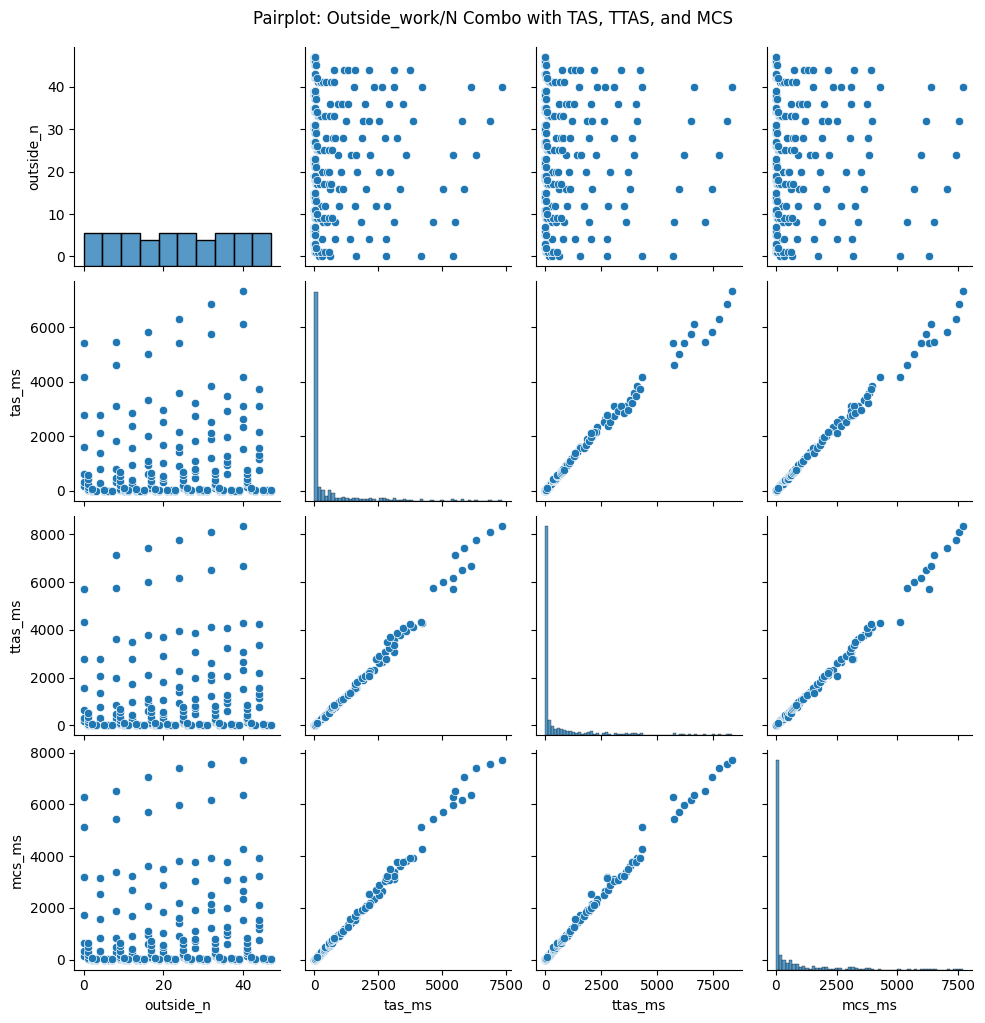

In [14]:
# Pairplot of outside_work and n, with mcs, ttas, tas

# Create a new column combining outside_work and n
df['outside_n'] = df['outside_work'].astype(str) + '_' + df['n'].astype(str)

# Encode 'outside_n' for use in pairplot as a pseudo-categorical variable
df['outside_n_code'] = LabelEncoder().fit_transform(df['outside_n'])

# Prepare dataframe for pairplot
pairplot_cols_outside_n = ['outside_n_code', 'tas_ms', 'ttas_ms', 'mcs_ms']
pairplot_data_outside_n = df[pairplot_cols_outside_n]
pairplot_data_outside_n = pairplot_data_outside_n.rename(columns={'outside_n_code': 'outside_n'})

sns.pairplot(pairplot_data_outside_n)
plt.suptitle("Pairplot: Outside_work/N Combo with TAS, TTAS, and MCS", y=1.02)
plt.show()

C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\2194658381.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_outside_n'] = (
C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\2194658381.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['threads_outside_n_code'] = LabelEncoder().fit_transform(df['threads_outside_n'])


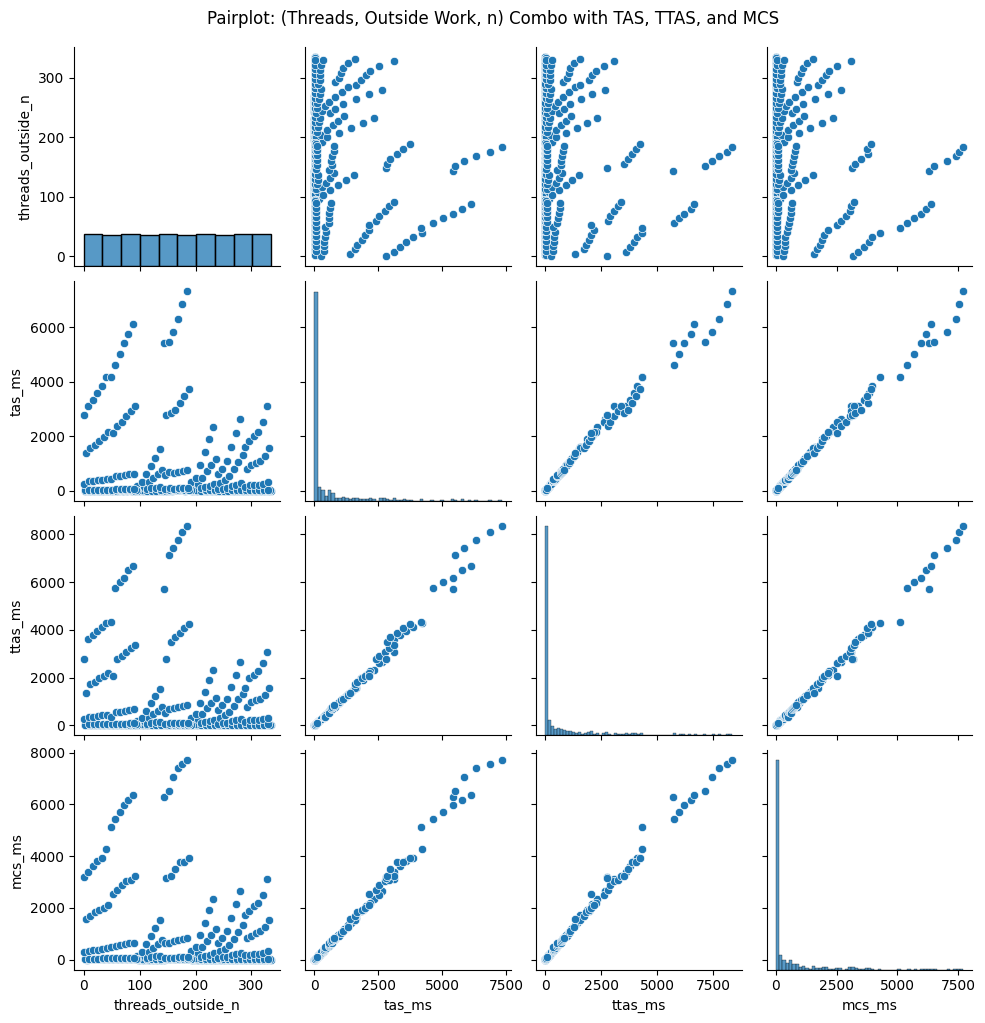

In [15]:

# Pairplot of threads, outside_work, and n, with mcs, ttas, tas

# For a true pairplot with all three variables (threads, outside_work, n) as explanatory/categorical axes,
# and lock times as the targets, we combine all three into a string code.
df['threads_outside_n'] = (
    df['threads'].astype(str) + '_' +
    df['outside_work'].astype(str) + '_' +
    df['n'].astype(str)
)

# Encode the joint label as a pseudo-categorical variable for pairplot
df['threads_outside_n_code'] = LabelEncoder().fit_transform(df['threads_outside_n'])

# Prepare the pairplot DataFrame
pairplot_cols_ton = ['threads_outside_n_code', 'tas_ms', 'ttas_ms', 'mcs_ms']
pairplot_data_ton = df[pairplot_cols_ton].rename(columns={'threads_outside_n_code': 'threads_outside_n'})

sns.pairplot(pairplot_data_ton)
plt.suptitle("Pairplot: (Threads, Outside Work, n) Combo with TAS, TTAS, and MCS", y=1.02)
plt.show()



#### Ranking for MCS

In [16]:
# Compute the rank (1 = fastest, 3 = slowest) for mcs_ms relative to tas_ms and ttas_ms
def rank_mcs(row):
    lock_times = [row["tas_ms"], row["ttas_ms"], row["mcs_ms"]]
    # Rank in ascending order, so 1 is the minimum
    sorted_times = sorted(lock_times)
    mcs_rank = sorted_times.index(row["mcs_ms"]) + 1  # +1 to convert 0-based to 1-based ranking
    return mcs_rank

df['mcs_rank'] = df.apply(rank_mcs, axis=1)

mcs_first = df[df.mcs_rank == 1][["threads", "outside_work", "n"]]

print(f"MCS is fastest in {len(mcs_first)} out of {len(df)} total cases ({len(mcs_first)/len(df)*100:.2f}%)")
print(mcs_first.n.value_counts()) # n nhỏ thì mcs có ưu thế hơn (CS time thấp)
print(mcs_first.threads.value_counts()) # thread count = 8 thì mcs có ưu thế hơn (not very clear)
print(mcs_first.outside_work.value_counts()) # outside_work = 1, 3, 5 thì mcs có ưu thế hơn



MCS is fastest in 157 out of 336 total cases (46.73%)
n
53        30
89        23
1009      23
101       22
503       22
50021     16
10007     15
100003     6
Name: count, dtype: int64
threads
1     31
8     29
12    26
16    26
20    24
4     11
2     10
Name: count, dtype: int64
outside_work
5    34
3    34
1    33
9    26
7    25
0     5
Name: count, dtype: int64


C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\4037504715.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mcs_rank'] = df.apply(rank_mcs, axis=1)


Number of cases where MCS is ranked 1st, grouped by threads and outside_work:

Pivot table (threads x outside_work) of MCS ranked 1st:



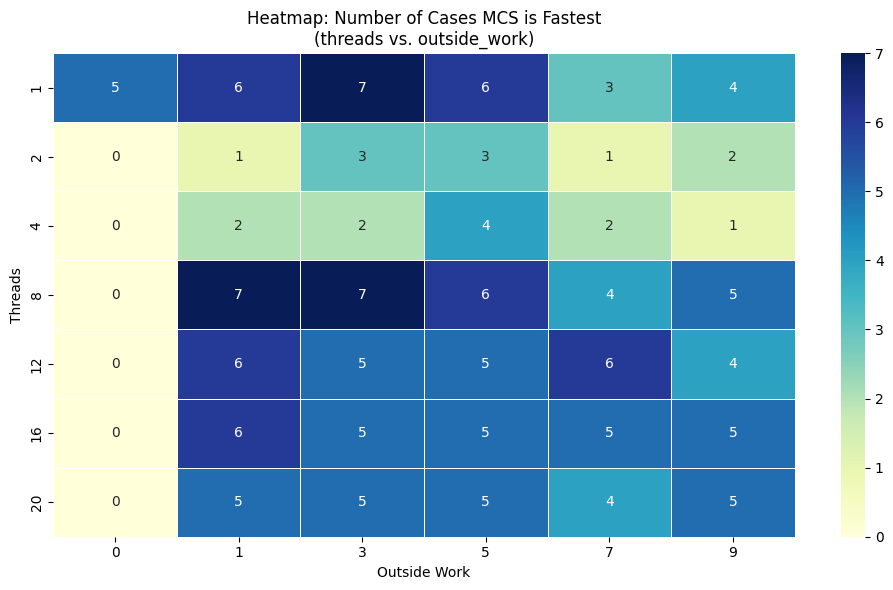

In [17]:
# Count how often MCS is ranked 1st, grouped by (threads, outside_work)
mcs_first_grouped = df[df.mcs_rank == 1].groupby(["threads", "outside_work"]).size().reset_index(name='count').sort_values(by='count', ascending=False)
print("Number of cases where MCS is ranked 1st, grouped by threads and outside_work:")
# mcs_first_grouped.head()

# Create a pivot table (threads x outside_work) for heatmap
mcs_first_pivot = mcs_first_grouped.pivot(index="threads", columns="outside_work", values="count").fillna(0).astype(int)
print("\nPivot table (threads x outside_work) of MCS ranked 1st:\n")
# print(mcs_first_pivot)

# Create a heatmap of the pivot table
plt.figure(figsize=(10, 6))
sns.heatmap(mcs_first_pivot, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Heatmap: Number of Cases MCS is Fastest\n(threads vs. outside_work)")
plt.xlabel("Outside Work")
plt.ylabel("Threads")
plt.tight_layout()
plt.show()

Number of cases where MCS is ranked 1st, grouped by threads and n:

Pivot table (threads x n) of MCS ranked 1st:



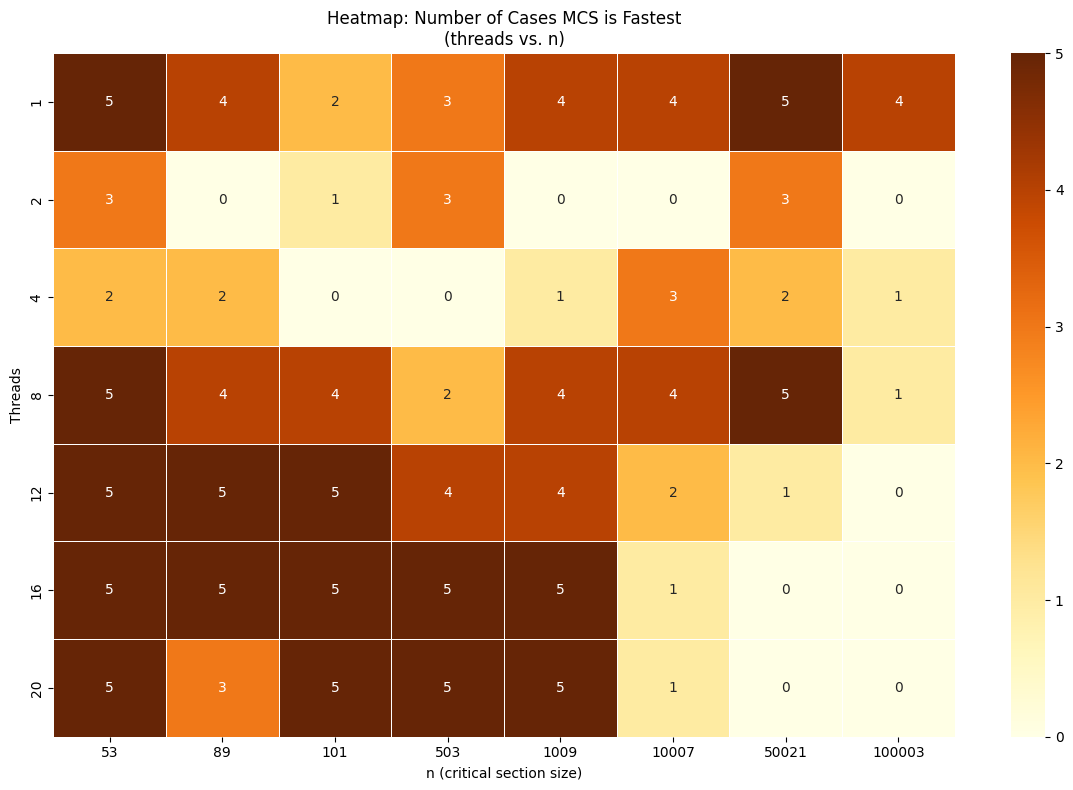

In [18]:
# Create a heatmap: number of cases where MCS is ranked 1st, grouped by (threads, n)
mcs_first_grouped_n = df[df.mcs_rank == 1].groupby(["threads", "n"]).size().reset_index(name='count').sort_values(by='count', ascending=False)
print("Number of cases where MCS is ranked 1st, grouped by threads and n:")

# Create a pivot table (threads x n) for heatmap
mcs_first_pivot_n = mcs_first_grouped_n.pivot(index="threads", columns="n", values="count").fillna(0).astype(int)
print("\nPivot table (threads x n) of MCS ranked 1st:\n")
# print(mcs_first_pivot_n)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(mcs_first_pivot_n, annot=True, fmt="d", cmap="YlOrBr", linewidths=0.5)
plt.title("Heatmap: Number of Cases MCS is Fastest\n(threads vs. n)")
plt.xlabel("n (critical section size)")
plt.ylabel("Threads")
plt.tight_layout()
plt.show()

Number of cases where MCS is ranked 1st, grouped by outside_work and n:

Pivot table (outside_work x n) of MCS ranked 1st:



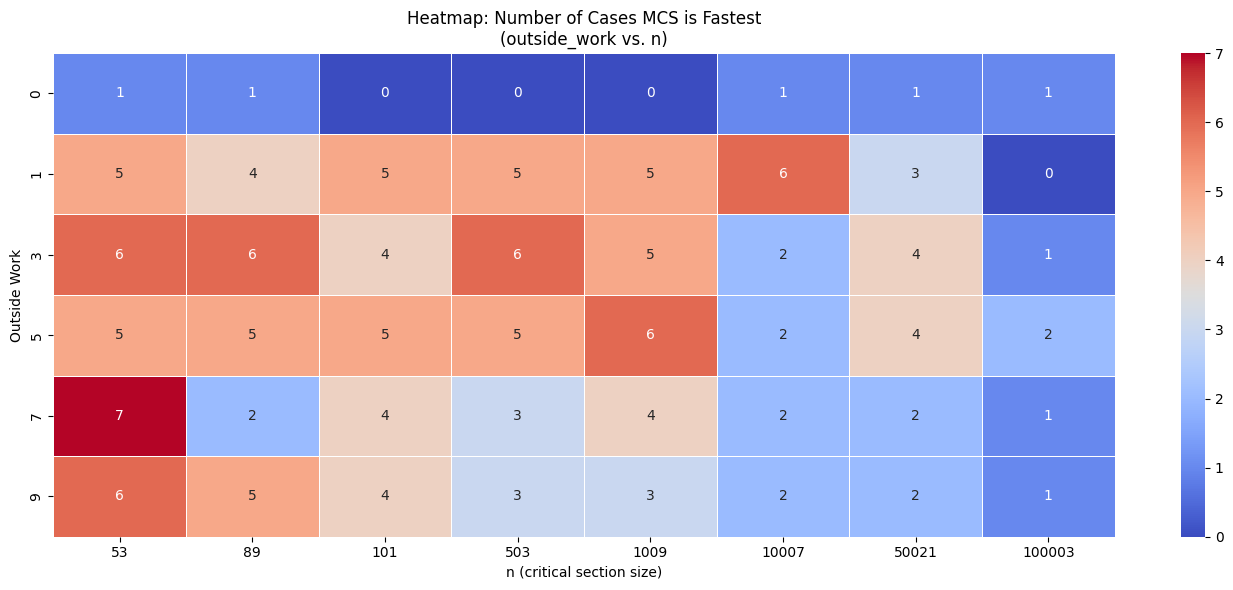

In [19]:
# Create a heatmap: number of cases where MCS is ranked 1st, grouped by (outside_work, n)
mcs_first_grouped_ow_n = df[df.mcs_rank == 1].groupby(["outside_work", "n"]).size().reset_index(name='count').sort_values(by='count', ascending=False)
print("Number of cases where MCS is ranked 1st, grouped by outside_work and n:")

# Create a pivot table (outside_work x n) for heatmap
mcs_first_pivot_ow_n = mcs_first_grouped_ow_n.pivot(index="outside_work", columns="n", values="count").fillna(0).astype(int)
print("\nPivot table (outside_work x n) of MCS ranked 1st:\n")
# print(mcs_first_pivot_ow_n)

# Plot the heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(mcs_first_pivot_ow_n, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap: Number of Cases MCS is Fastest\n(outside_work vs. n)")
plt.xlabel("n (critical section size)")
plt.ylabel("Outside Work")
plt.tight_layout()
plt.show()

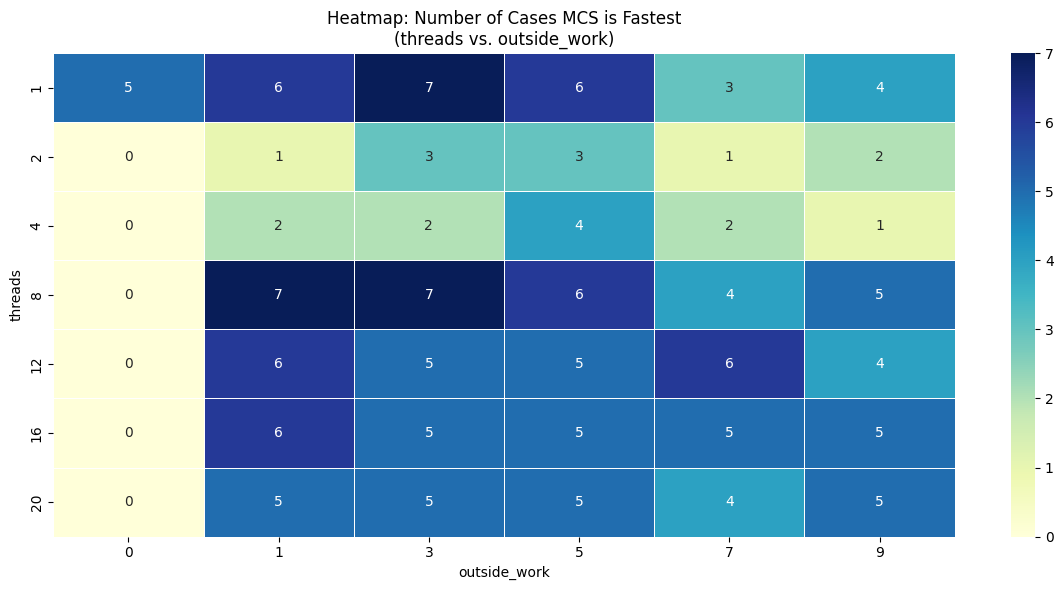

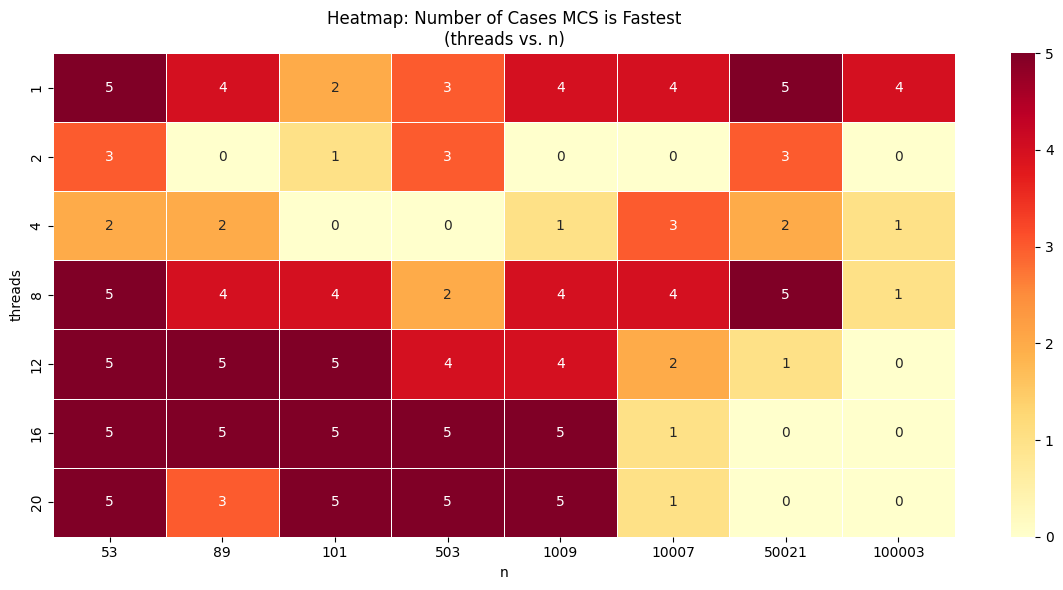

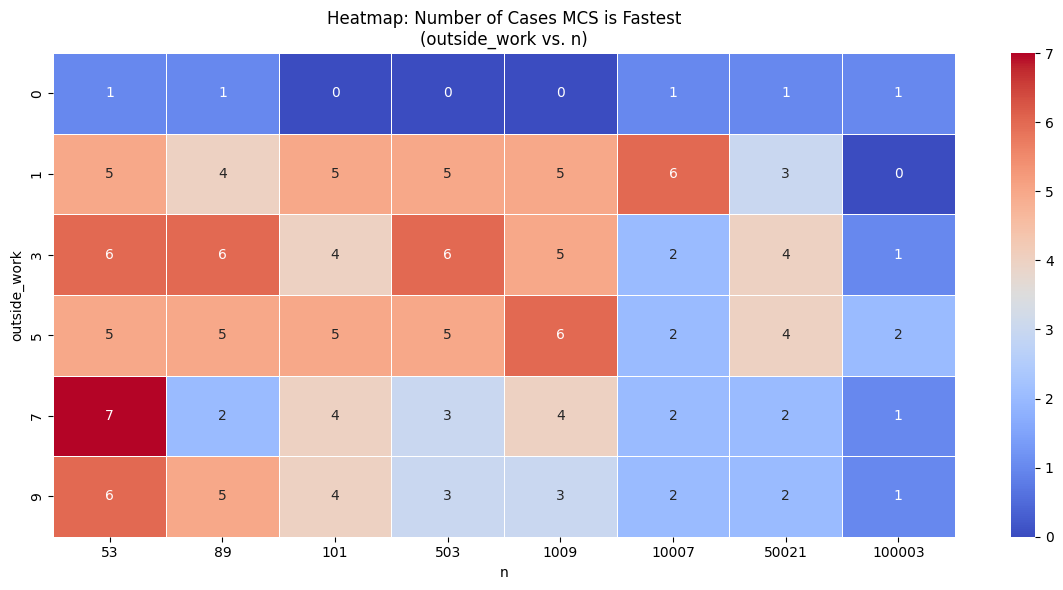

In [20]:
# Create 3 heat maps grouped by: (1) threads + outside_work, (2) threads + n, (3) outside_work + n for MCS fastest cases

import matplotlib.pyplot as plt
import seaborn as sns

def plot_mcs_first_heatmap(group_cols, figsize=(12, 6), cmap="YlGnBu"):
    mcs_first_grouped = (
        df[df.mcs_rank == 1]
        .groupby(group_cols)
        .size()
        .reset_index(name="count")
        .sort_values(by="count", ascending=False)
    )
    pivot = mcs_first_grouped.pivot(index=group_cols[0], columns=group_cols[1], values="count").fillna(0).astype(int)
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt="d", cmap=cmap, linewidths=0.5)
    plt.title(f"Heatmap: Number of Cases MCS is Fastest\n({group_cols[0]} vs. {group_cols[1]})")
    plt.xlabel(group_cols[1])
    plt.ylabel(group_cols[0])
    plt.tight_layout()
    plt.show()

# (1) threads x outside_work
plot_mcs_first_heatmap(["threads", "outside_work"], figsize=(12, 6), cmap="YlGnBu")

# (2) threads x n
plot_mcs_first_heatmap(["threads", "n"], figsize=(12, 6), cmap="YlOrRd")

# (3) outside_work x n
plot_mcs_first_heatmap(["outside_work", "n"], figsize=(12, 6), cmap="coolwarm")


Conclusion
- MCS performs best mainly when the critical section is short to moderate, which is reflected by smaller values of n. Across the heatmaps, MCS wins are concentrated at low n such as 53, 89, 101, 503, and 1009, while its advantage drops noticeably as n becomes very large, especially at 100003. This suggests MCS is effective when lock-management efficiency matters more than the amount of work inside the critical section.

- In terms of contention, MCS shows a fairly stable advantage across medium to high thread counts, especially 8, 12, 16, and 20 threads. Unlike TTAS, MCS does not benefit from outside_work = 0; in fact, it wins much more often when outside_work is moderate, particularly at 1, 3, and 5. This indicates that MCS is well suited to settings with sustained contention and more balanced workloads, where fairness and orderly lock handoff help reduce the cost of contention.

- Overall, the MCS heatmaps suggest that MCS is the most robust lock for high-contention scenarios with relatively short critical sections. Its advantage is driven by scalable behavior under many competing threads rather than by large computation inside the critical section, making it a strong choice when contention control is more important than raw lock simplicity

#### Ranking for TAS

In [21]:
# Compute the rank (1 = fastest, 3 = slowest) for tas_ms relative to ttas_ms and mcs_ms
def rank_tas(row):
    lock_times = [row["tas_ms"], row["ttas_ms"], row["mcs_ms"]]
    sorted_times = sorted(lock_times)
    tas_rank = sorted_times.index(row["tas_ms"]) + 1  # +1 to convert 0-based to 1-based ranking
    return tas_rank

df['tas_rank'] = df.apply(rank_tas, axis=1)

tas_first = df[df.tas_rank == 1][["threads", "outside_work", "n"]]

print(f"TAS is fastest in {len(tas_first)} out of {len(df)} total cases ({len(tas_first)/len(df)*100:.2f}%)")

print(tas_first.n.value_counts()) # tas có ưu thế hơn khi n lớn (CS time > lock time)
print(tas_first.threads.value_counts()) # thread count = 4, 8 (chưa rõ)
print(tas_first.outside_work.value_counts()) # outside_work = 3, 0, 5 (chưa rõ)

TAS is fastest in 111 out of 336 total cases (33.04%)
n
100003    26
50021     21
10007     18
503       12
1009      12
101       11
89         9
53         2
Name: count, dtype: int64
threads
4     23
2     22
20    18
16    15
1     13
12    11
8      9
Name: count, dtype: int64
outside_work
7    23
9    20
1    19
0    19
5    16
3    14
Name: count, dtype: int64


C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\1183675436.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tas_rank'] = df.apply(rank_tas, axis=1)


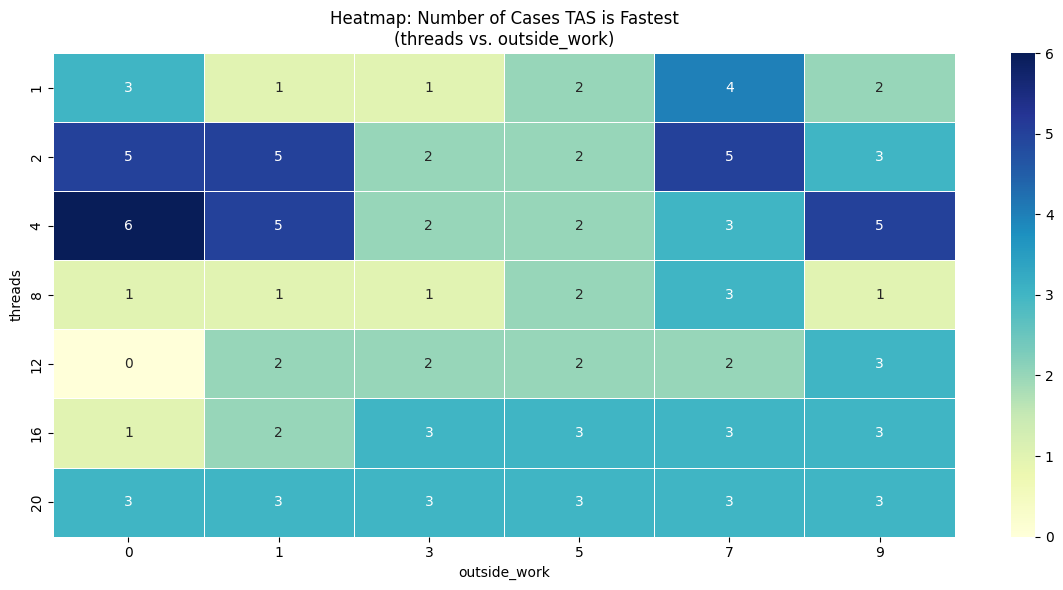

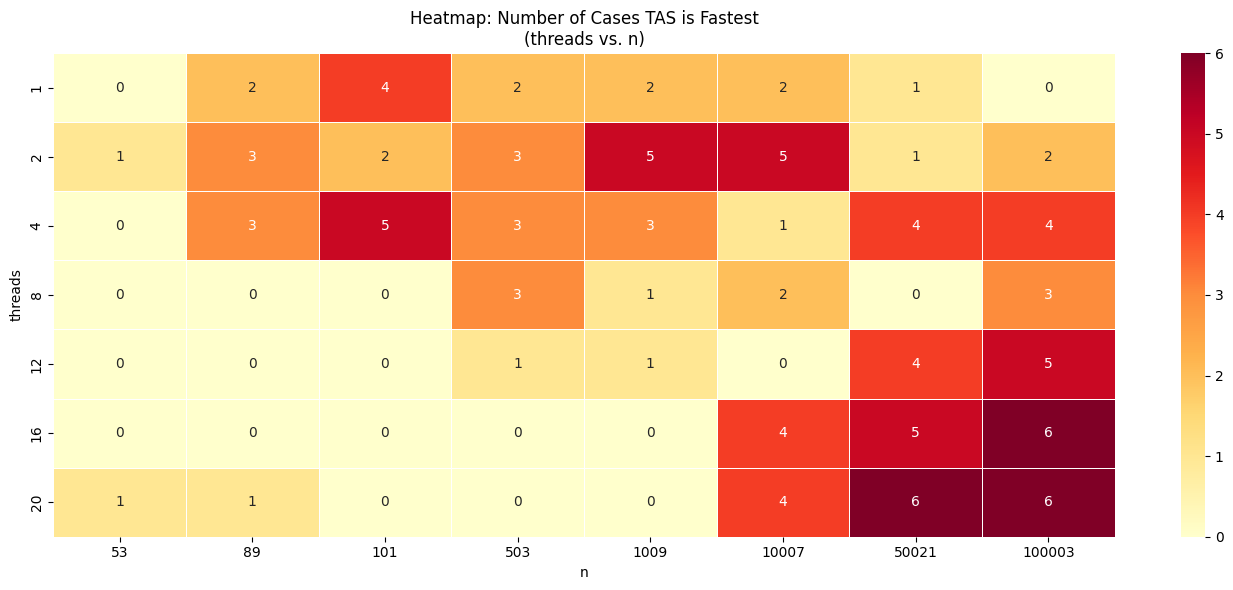

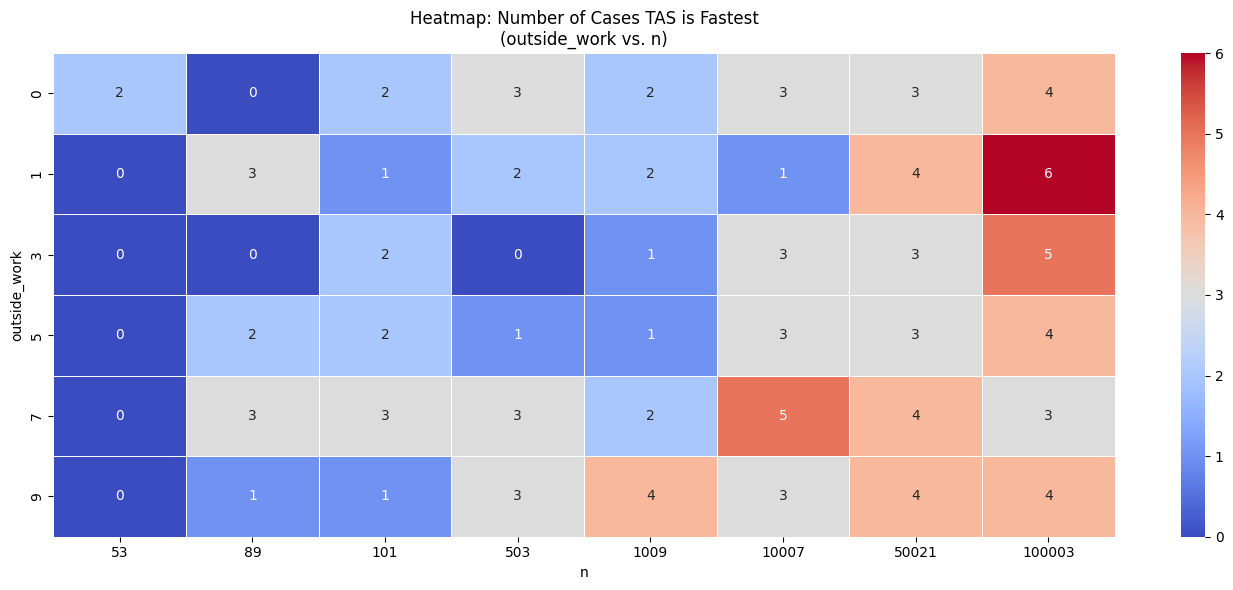

In [22]:
def plot_tas_first_heatmap(group_cols, figsize=(12, 6), cmap="coolwarm"):
    # Group by the specified columns for cases where TAS is ranked 1st
    tas_first_grouped = (
        df[df.tas_rank == 1]
        .groupby(group_cols)
        .size()
        .reset_index(name="count")
        .sort_values(by="count", ascending=False)
    )
    # Create a pivot table for the heatmap
    pivot = tas_first_grouped.pivot(index=group_cols[0], columns=group_cols[1], values="count").fillna(0).astype(int)
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt="d", cmap=cmap, linewidths=0.5)
    plt.title(f"Heatmap: Number of Cases TAS is Fastest\n({group_cols[0]} vs. {group_cols[1]})")
    plt.xlabel(group_cols[1])
    plt.ylabel(group_cols[0])
    plt.tight_layout()
    plt.show()

# Heatmap 1: threads + outside_work
plot_tas_first_heatmap(["threads", "outside_work"], figsize=(12, 6), cmap="YlGnBu")

# Heatmap 2: threads + n
plot_tas_first_heatmap(["threads", "n"], figsize=(14, 6), cmap="YlOrRd")

# Heatmap 3: outside_work + n
plot_tas_first_heatmap(["outside_work", "n"], figsize=(14, 6), cmap="coolwarm")

Conclusion
- TAS shows a clearer advantage as the critical section becomes larger, which in this experiment is reflected by larger values of n. Across the heatmaps, TAS wins are concentrated much more strongly at medium-to-large n, especially 10007, 50021, and 100003, while it rarely wins at very small n such as 53. This suggests TAS benefits when the useful work inside the critical section dominates the locking overhead.

- The effect of thread count is less uniform than the effect of n. TAS performs reasonably well at low-to-moderate thread counts such as 2 and 4, but it also remains competitive at 16 and 20 threads when n is large. In contrast to TTAS, TAS does not depend on one narrow outside_work setting; its wins are spread across different outside_work values, with a slight concentration at higher outside_work such as 7 and 9. This indicates TAS is not tied to a single contention pattern, but instead benefits more from workloads where lock overhead becomes relatively less important.

- Overall, the TAS heatmaps suggest that TAS is most suitable when the *critical section is long* and the lock cost is amortized by larger computation

#### ranking for TTAS

In [23]:
# Compute the rank (1 = fastest, 3 = slowest) for ttas_ms relative to tas_ms and mcs_ms
def rank_ttas(row):
    lock_times = [row["tas_ms"], row["ttas_ms"], row["mcs_ms"]]
    sorted_times = sorted(lock_times)
    ttas_rank = sorted_times.index(row["ttas_ms"]) + 1  # +1 to convert 0-based to 1-based ranking
    return ttas_rank

df['ttas_rank'] = df.apply(rank_ttas, axis=1)

ttas_first = df[df.ttas_rank == 1][["threads", "outside_work", "n"]]

print(f"TTAS is fastest in {len(ttas_first)} out of {len(df)} total cases ({len(ttas_first)/len(df)*100:.2f}%)")

print(ttas_first.n.value_counts()) # n = 1009 (CS time vừa phải)
print(ttas_first.threads.value_counts()) # thread count = 12, 16, 20 (high contention) (chưa rõ)
print(ttas_first.outside_work.value_counts()) # ttas có lợi thế khi outside word = 0 (high contention - thread acquire liên tục)

#


TTAS is fastest in 68 out of 336 total cases (20.24%)
n
100003    10
53        10
89        10
101        9
10007      9
503        8
1009       7
50021      5
Name: count, dtype: int64
threads
2     16
4     14
12    11
8     10
16     7
20     6
1      4
Name: count, dtype: int64
outside_work
0    32
9    10
3     8
7     8
5     6
1     4
Name: count, dtype: int64


C:\Users\Phu Nguyen\AppData\Local\Temp\ipykernel_6544\2659299032.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ttas_rank'] = df.apply(rank_ttas, axis=1)


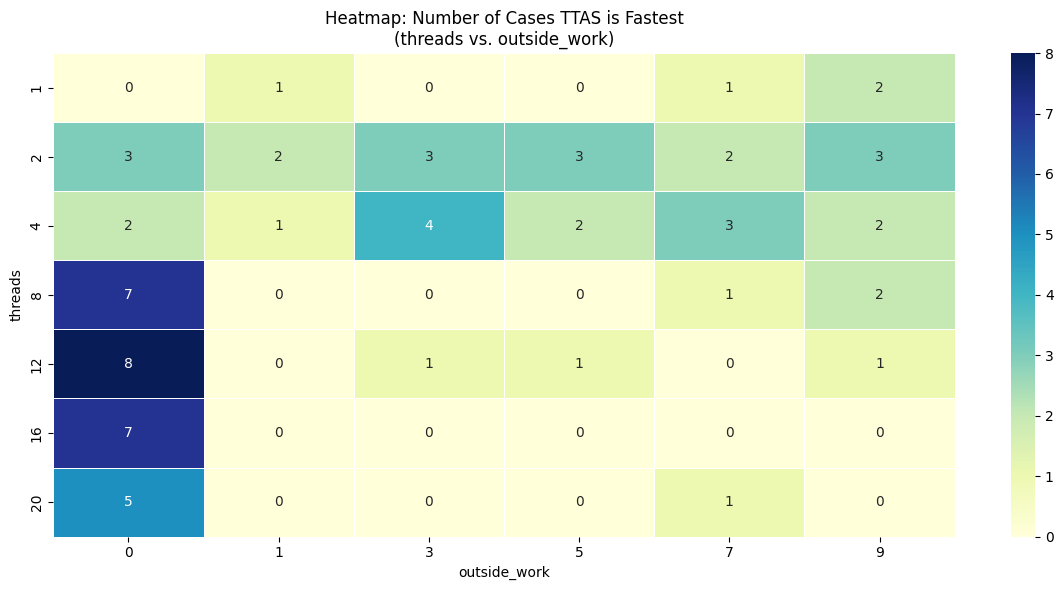

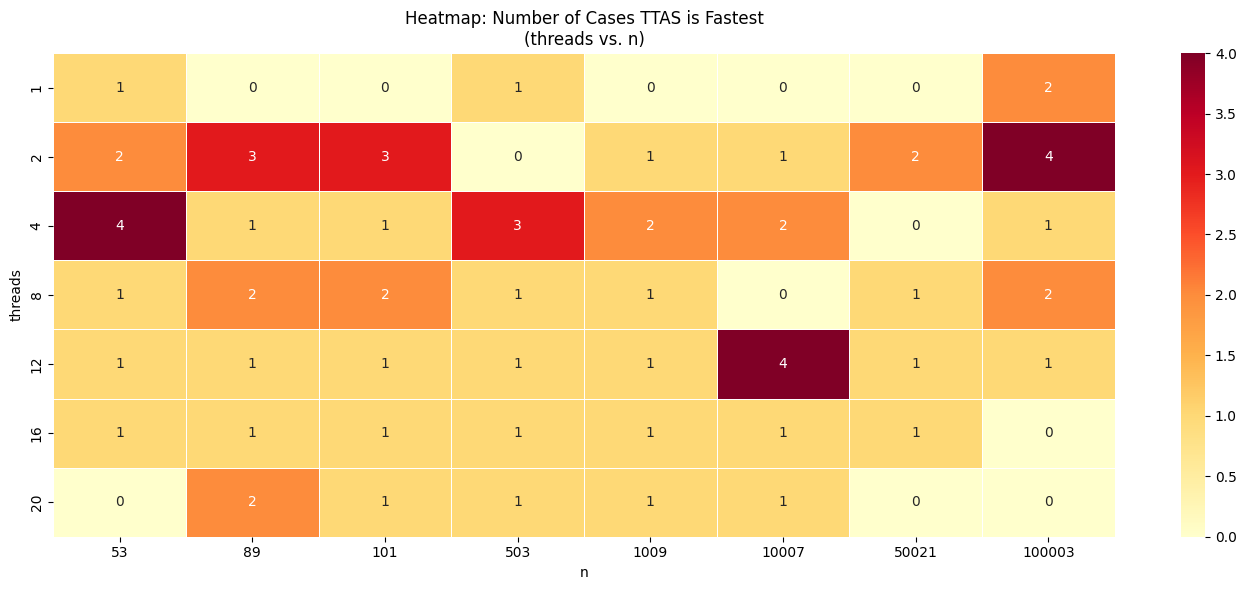

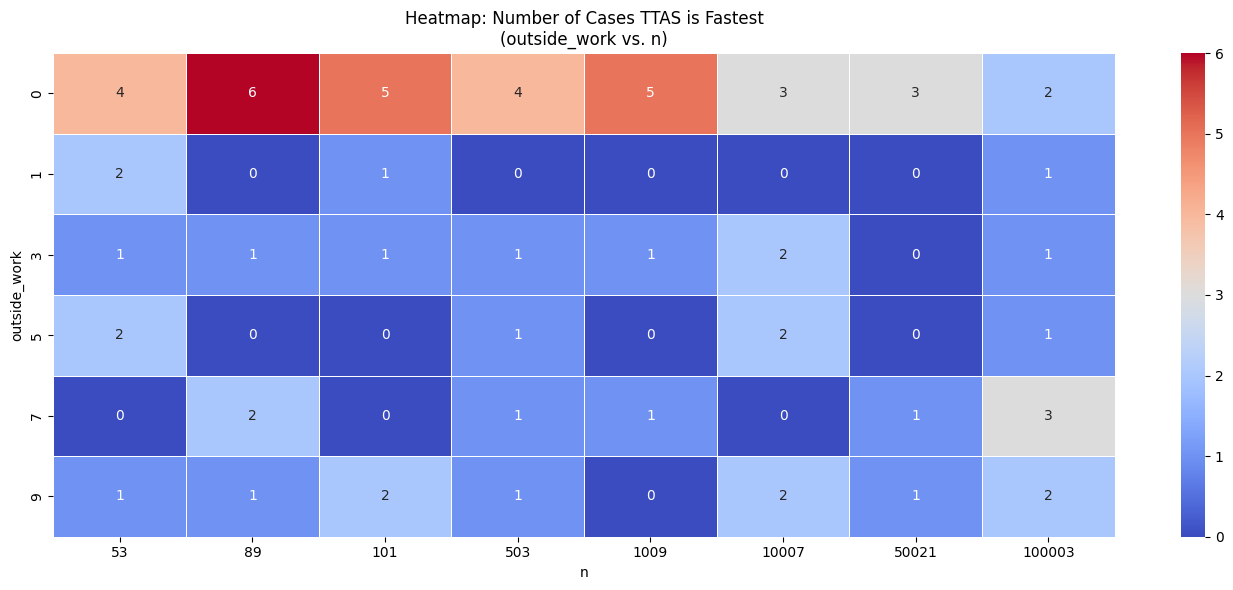

In [24]:
def plot_ttas_first_heatmap(group_cols, figsize=(12, 6), cmap="coolwarm"):
    # Group by the specified columns for cases where TTAS is ranked 1st
    ttas_first_grouped = (
        df[df.ttas_rank == 1]
        .groupby(group_cols)
        .size()
        .reset_index(name="count")
        .sort_values(by="count", ascending=False)
    )
    # print(ttas_first_grouped)
    # Create a pivot table for the heatmap
    pivot = ttas_first_grouped.pivot(index=group_cols[0], columns=group_cols[1], values="count").fillna(0).astype(int)
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt="d", cmap=cmap, linewidths=0.5)
    plt.title(f"Heatmap: Number of Cases TTAS is Fastest\n({group_cols[0]} vs. {group_cols[1]})")
    plt.xlabel(group_cols[1])
    plt.ylabel(group_cols[0])
    plt.tight_layout()
    plt.show()

# Heatmap 1 for TTAS: threads + outside_work
plot_ttas_first_heatmap(["threads", "outside_work"], figsize=(12, 6), cmap="YlGnBu")

# Heatmap 2 for TTAS: threads + n
plot_ttas_first_heatmap(["threads", "n"], figsize=(14, 6), cmap="YlOrRd")

# Heatmap 3 for TTAS: outside_work + n
plot_ttas_first_heatmap(["outside_work", "n"], figsize=(14, 6), cmap="coolwarm")

 Conclusions on each heatmap of TTAS:
- Heatmap 1 and Heatmap 3 show a consistent pattern for TTAS. In both views, TTAS performs best when outside_work is very small, especially at outside_work = 0, which corresponds to frequent lock re-attempts and high contention. Heatmap 1 shows that under this condition, TTAS can win even at higher thread counts such as 8, 12, 16, and 20, while Heatmap 3 confirms that this advantage is tied more strongly to low outside_work than to any single n range. Together, these two heatmaps suggest that TTAS benefits most when threads repeatedly compete for the lock with little delay between attempts.

- Heatmap 2 looks different because it aggregates over all outside_work values and therefore hides the narrow condition that makes TTAS strong. Although TTAS can perform well at high thread counts when outside_work = 0, that advantage does not hold across larger outside_work values. As a result, once all outside_work settings are combined, high-thread TTAS wins become less frequent overall, and the heatmap shows more wins at lower thread counts such as 2 and 4. This is an aggregation effect: a strong pattern in one specific slice of the data becomes diluted when another dimension is collapsed.

- Overall, TTAS advantage is in high-contention settings where outside_work is minimal, but that advantage weakens when contention is reduced by additional outside work



In [25]:
# Kết luận
# Khi CS ngắn + outside work vừa phải => MCS có ưu thế hơn TAS và TTAS
# CS time lớn, lớn hơn lock time => TAS có lợi thế
# số lượng thread nhiều, thread cạnh tranh critical section nhiều => TTAS có lợi thế
# MCS chiếm 45.83% số trường hợp, TTAS chiếm 38.89%, TAS chiếm 15.28%

In [26]:
# raise RuntimeError("I want to stop here")

### Lock with exponential backoff

#### TAS in exponential backoff

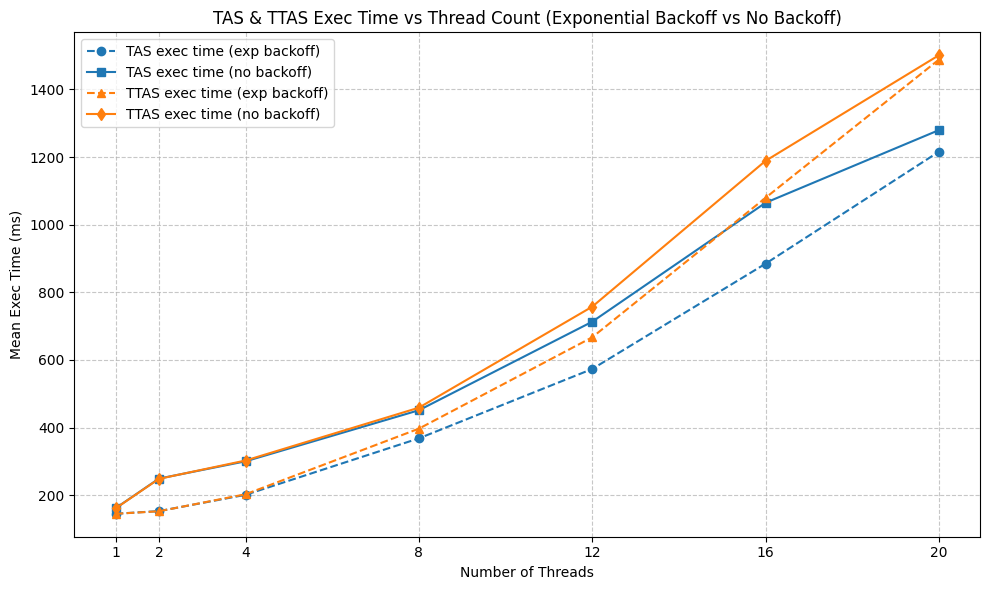

In [45]:
import matplotlib.pyplot as plt

# Draw line chart: threads vs TAS and TTAS exec time for exponential backoff,
# keeping the same color for each lock type

tas_color = "#1f77b4"   # blue for TAS
ttas_color = "#ff7f0e"  # orange for TTAS

tas_thread_backoff = df_with_exponential_backoff.groupby("threads")["tas_ms"].mean().reset_index()
ttas_thread_backoff = df_with_exponential_backoff.groupby("threads")["ttas_ms"].mean().reset_index()

tas_thread_no_backoff = df.groupby("threads")["tas_ms"].mean().reset_index()
ttas_thread_no_backoff = df.groupby("threads")["ttas_ms"].mean().reset_index()

plt.figure(figsize=(10, 6))

# No backoff = dashed line, backoff = solid (normal) line
plt.plot(
    tas_thread_backoff["threads"], 
    tas_thread_backoff["tas_ms"],
    marker="o",
    color=tas_color,
    linestyle="--",
    label="TAS exec time (exp backoff)"
)
plt.plot(
    tas_thread_no_backoff["threads"], 
    tas_thread_no_backoff["tas_ms"], 
    marker="s", 
    linestyle="-", 
    color=tas_color,
    label="TAS exec time (no backoff)"
)
plt.plot(
    ttas_thread_backoff["threads"], 
    ttas_thread_backoff["ttas_ms"], 
    marker="^", 
    color=ttas_color,
    linestyle="--",
    label="TTAS exec time (exp backoff)"
)
plt.plot(
    ttas_thread_no_backoff["threads"], 
    ttas_thread_no_backoff["ttas_ms"], 
    marker="d", 
    linestyle="-", 
    color=ttas_color,
    label="TTAS exec time (no backoff)"
)

plt.title("TAS & TTAS Exec Time vs Thread Count (Exponential Backoff vs No Backoff)")
plt.xlabel("Number of Threads")
plt.ylabel("Mean Exec Time (ms)")
plt.xticks(sorted(list(
    set(tas_thread_backoff["threads"])
    .union(set(tas_thread_no_backoff["threads"]))
    .union(set(ttas_thread_backoff["threads"]))
    .union(set(ttas_thread_no_backoff["threads"]))
)))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

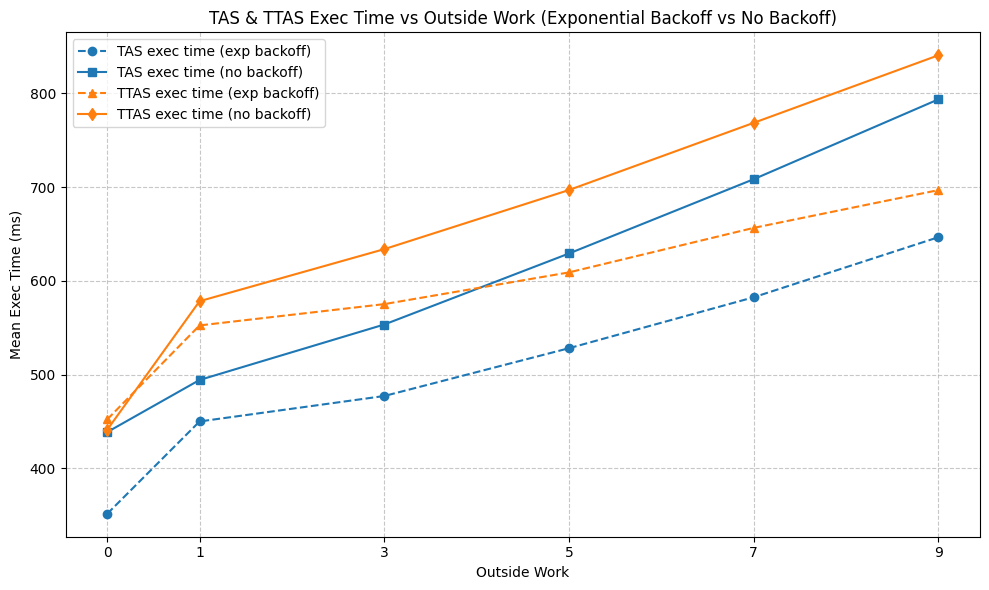

In [42]:
# Draw line chart: outside work vs TAS and TTAS exec time for both exponential backoff and non-backoff,
# keeping the same color for each lock type/style

# Filter DataFrame for both backoff (use_backoff == 1) and no backoff (use_backoff == 0)
# Group by outside_work for mean times by lock type and backoff state
tas_exp = df_with_exponential_backoff.groupby("outside_work")["tas_ms"].mean().reset_index()
tas_noexp = df.groupby("outside_work")["tas_ms"].mean().reset_index()
ttas_exp = df_with_exponential_backoff.groupby("outside_work")["ttas_ms"].mean().reset_index()
ttas_noexp = df.groupby("outside_work")["ttas_ms"].mean().reset_index()

# Use consistent colors
tas_color = "#1f77b4"
ttas_color = "#ff7f0e"

plt.figure(figsize=(10, 6))
plt.plot(tas_exp["outside_work"], tas_exp["tas_ms"],
         marker="o", linestyle="--", color=tas_color, label="TAS exec time (exp backoff)")
plt.plot(tas_noexp["outside_work"], tas_noexp["tas_ms"],
         marker="s", linestyle="-", color=tas_color, label="TAS exec time (no backoff)")
plt.plot(ttas_exp["outside_work"], ttas_exp["ttas_ms"],
         marker="^", linestyle="--", color=ttas_color, label="TTAS exec time (exp backoff)")
plt.plot(ttas_noexp["outside_work"], ttas_noexp["ttas_ms"],
         marker="d", linestyle="-", color=ttas_color, label="TTAS exec time (no backoff)")

plt.title("TAS & TTAS Exec Time vs Outside Work (Exponential Backoff vs No Backoff)")
plt.xlabel("Outside Work")
plt.ylabel("Mean Exec Time (ms)")
plt.xticks(sorted(set(df["outside_work"])))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

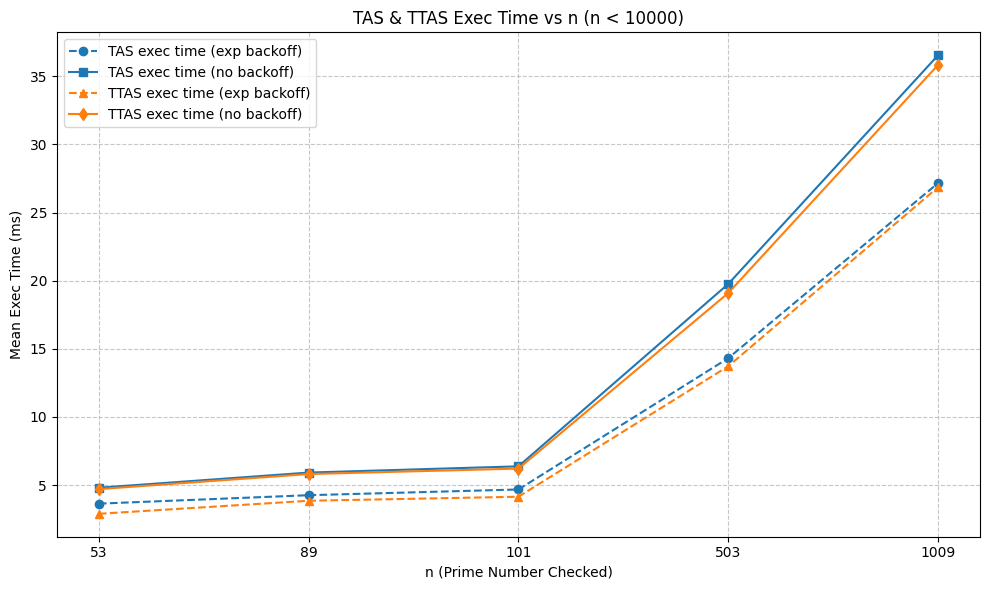

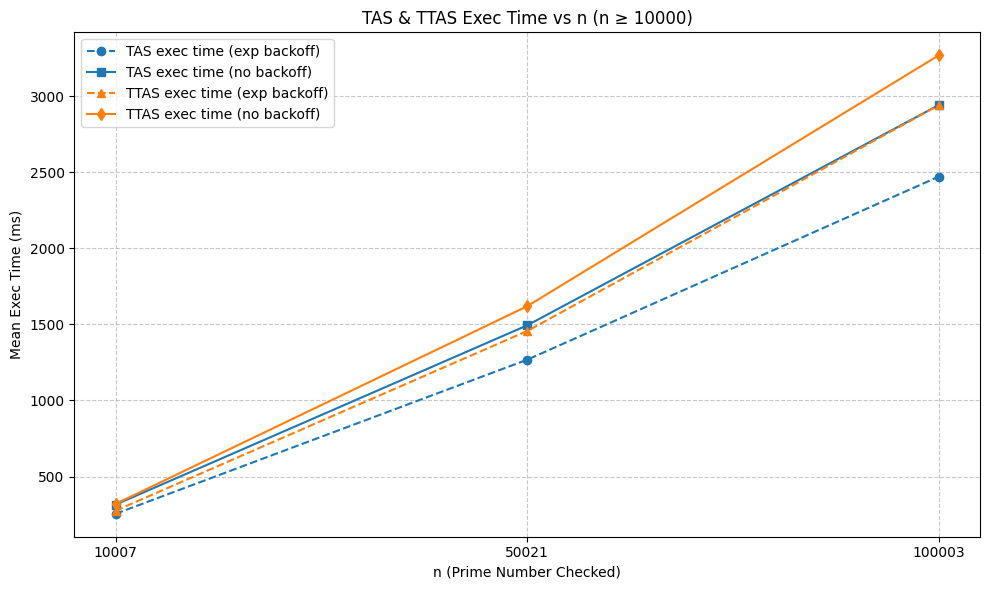

In [47]:
# Compare in two ranges of n for clarity

# Split n into two ranges: small (n < 10,000) and large (n >= 10,000)
split_n = 10000

# Prepare data breakdown by n as before
tas_exp_n = df_with_exponential_backoff.groupby("n")["tas_ms"].mean().reset_index()
tas_noexp_n = df.groupby("n")["tas_ms"].mean().reset_index()
ttas_exp_n = df_with_exponential_backoff.groupby("n")["ttas_ms"].mean().reset_index()
ttas_noexp_n = df.groupby("n")["ttas_ms"].mean().reset_index()

# Choose small and big n ranges
tas_exp_n_small = tas_exp_n[tas_exp_n["n"] < split_n].copy()
tas_noexp_n_small = tas_noexp_n[tas_noexp_n["n"] < split_n].copy()
ttas_exp_n_small = ttas_exp_n[ttas_exp_n["n"] < split_n].copy()
ttas_noexp_n_small = ttas_noexp_n[ttas_noexp_n["n"] < split_n].copy()

tas_exp_n_big = tas_exp_n[tas_exp_n["n"] >= split_n].copy()
tas_noexp_n_big = tas_noexp_n[tas_noexp_n["n"] >= split_n].copy()
ttas_exp_n_big = ttas_exp_n[ttas_exp_n["n"] >= split_n].copy()
ttas_noexp_n_big = ttas_noexp_n[ttas_noexp_n["n"] >= split_n].copy()

# Convert n to string so it displays better on the x-axis
tas_exp_n_small["n"] = tas_exp_n_small["n"].astype(str)
tas_noexp_n_small["n"] = tas_noexp_n_small["n"].astype(str)
ttas_exp_n_small["n"] = ttas_exp_n_small["n"].astype(str)
ttas_noexp_n_small["n"] = ttas_noexp_n_small["n"].astype(str)
tas_exp_n_big["n"] = tas_exp_n_big["n"].astype(str)
tas_noexp_n_big["n"] = tas_noexp_n_big["n"].astype(str)
ttas_exp_n_big["n"] = ttas_exp_n_big["n"].astype(str)
ttas_noexp_n_big["n"] = ttas_noexp_n_big["n"].astype(str)

tas_color = "#1f77b4"
ttas_color = "#ff7f0e"

# Small n chart
plt.figure(figsize=(10, 6))
plt.plot(
    tas_exp_n_small["n"], tas_exp_n_small["tas_ms"],
    marker="o", linestyle="--", color=tas_color, label="TAS exec time (exp backoff)"
)
plt.plot(
    tas_noexp_n_small["n"], tas_noexp_n_small["tas_ms"],
    marker="s", linestyle="-", color=tas_color, label="TAS exec time (no backoff)"
)
plt.plot(
    ttas_exp_n_small["n"], ttas_exp_n_small["ttas_ms"],
    marker="^", linestyle="--", color=ttas_color, label="TTAS exec time (exp backoff)"
)
plt.plot(
    ttas_noexp_n_small["n"], ttas_noexp_n_small["ttas_ms"],
    marker="d", linestyle="-", color=ttas_color, label="TTAS exec time (no backoff)"
)
plt.title(f"TAS & TTAS Exec Time vs n (n < {split_n})")
plt.xlabel("n (Prime Number Checked)")
plt.ylabel("Mean Exec Time (ms)")
plt.xticks(
    sorted(
        set(tas_exp_n_small["n"].tolist() + tas_noexp_n_small["n"].tolist() +
            ttas_exp_n_small["n"].tolist() + ttas_noexp_n_small["n"].tolist()),
        key=int
    )
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Large n chart
plt.figure(figsize=(10, 6))
plt.plot(
    tas_exp_n_big["n"], tas_exp_n_big["tas_ms"],
    marker="o", linestyle="--", color=tas_color, label="TAS exec time (exp backoff)"
)
plt.plot(
    tas_noexp_n_big["n"], tas_noexp_n_big["tas_ms"],
    marker="s", linestyle="-", color=tas_color, label="TAS exec time (no backoff)"
)
plt.plot(
    ttas_exp_n_big["n"], ttas_exp_n_big["ttas_ms"],
    marker="^", linestyle="--", color=ttas_color, label="TTAS exec time (exp backoff)"
)
plt.plot(
    ttas_noexp_n_big["n"], ttas_noexp_n_big["ttas_ms"],
    marker="d", linestyle="-", color=ttas_color, label="TTAS exec time (no backoff)"
)
plt.title(f"TAS & TTAS Exec Time vs n (n ≥ {split_n})")
plt.xlabel("n (Prime Number Checked)")
plt.ylabel("Mean Exec Time (ms)")
plt.xticks(
    sorted(
        set(tas_exp_n_big["n"].tolist() + tas_noexp_n_big["n"].tolist() +
            ttas_exp_n_big["n"].tolist() + ttas_noexp_n_big["n"].tolist()),
        key=int
    )
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Cost of lock

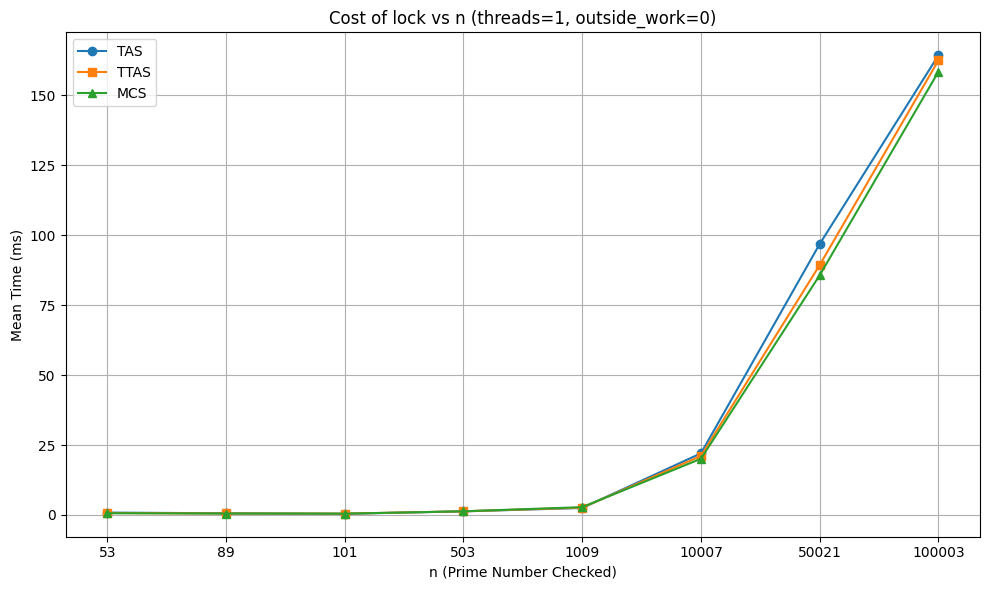

In [28]:
# Fix thread and outside_work to small values (e.g., threads=4, outside_work=0) to compare lock cost across n
fixed_threads = 1
fixed_outside_work = 0

df_lockcost = df[
    (df["threads"] == fixed_threads) &
    (df["outside_work"] == fixed_outside_work)
].sort_values("n")
df_lockcost["n"] = df_lockcost["n"].astype(str)

plt.figure(figsize=(10, 6))
plt.plot(df_lockcost["n"], df_lockcost["tas_ms"], marker='o', label="TAS")
plt.plot(df_lockcost["n"], df_lockcost["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_lockcost["n"], df_lockcost["mcs_ms"], marker='^', label="MCS")

plt.title(f"Cost of lock vs n (threads={fixed_threads}, outside_work={fixed_outside_work})")
plt.xlabel("n (Prime Number Checked)")
plt.ylabel("Mean Time (ms)")
plt.xticks(df_lockcost["n"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Performance and Scalability analysis

In [29]:
# df = read_file("result.csv")

#### 1. Low thread + 0 outside work + low prime number
- Baseline overhead of each lock with no outside noise.

In [30]:
# fixed_n = 1009  # one of the low primes used in your data
# fixed_outside_work = 2

# # Filter and group, then compute the mean for each lock at every thread count
# df_scalability = df[
#     (df["outside_work"] <= fixed_outside_work)
# ].groupby("threads")[["tas_ms", "ttas_ms", "mcs_ms"]].mean().reset_index().sort_values("threads")

# plt.figure(figsize=(10, 6))
# plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
# plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
# plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

# plt.title(f"Mean Execution Time vs Thread Count (n<={fixed_n}, outside work<={fixed_outside_work})")
# plt.xlabel("Thread Count")
# plt.ylabel("Mean Time (ms)")
# plt.legend()
# plt.grid(True)
# plt.show()

#### 2. High thread + 0 outside work + low prime number
- The MCS "Win": Max contention and high traffic.

#### 3. Low thread + 0 outside work + High prime number
- Does a long CS make the lock type less relevant?

#### 4.High thread + 0 outside work + High prime number
- 

#### 5. Low thread + 5 outside work + Low prime number
- Scenario where TAS might beat MCS due to lower overhead.

#### 6. High thread + 5 outside work + Low prime number
- Does the interconnect still choke even with outside work?

#### 7. Low thread + 5 outside work + High prime number
- Low-load baseline for long-running critical sections.

#### 8. High thread + 5 outside work + High prime number
- Scalability test under "realistic" staggered arrival rates.

### Experiment Analysis

#### 1. Scalability
- How the performance changes with different thread count

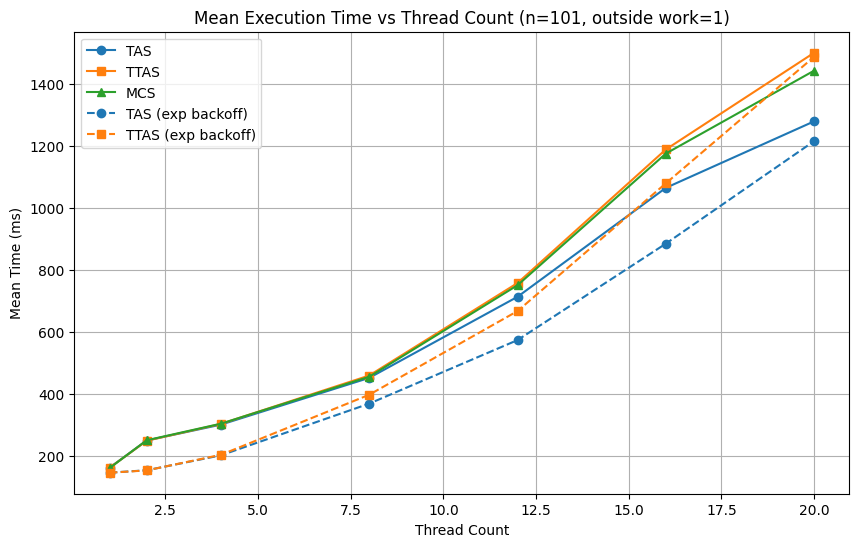

In [31]:
fixed_n = 101  # one of the low primes used in your data
fixed_outside_work = 1

# Group by thread count and compute mean execution time for each lock
# df_scalability = df[
#     (df["n"] == fixed_n) &
#     (df["outside_work"] == fixed_outside_work)
# ]
df_scalability = df


# Prepare exponential backoff data for plotting
# expbackoff_scalability = df_with_exponential_backoff[
#     (df_with_exponential_backoff["n"] == fixed_n) &
#     (df_with_exponential_backoff["outside_work"] == fixed_outside_work)
# ]
expbackoff_scalability = df_with_exponential_backoff

###############

df_scalability = df_scalability.groupby("threads", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("threads")

plt.figure(figsize=(10, 6))
plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

expbackoff_scalability = expbackoff_scalability.groupby("threads", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("threads")

# Plot TAS exp backoff with same color/marker and dashed line
plt.plot(
    df_scalability["threads"],
    expbackoff_scalability["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)

# Plot TTAS exp backoff with same color/marker and dashed line
plt.plot(
    df_scalability["threads"],
    expbackoff_scalability["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)



plt.title(f"Mean Execution Time vs Thread Count (n={fixed_n}, outside work={fixed_outside_work})")
plt.xlabel("Thread Count")
plt.ylabel("Mean Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 2. Contention
- How the performance changes with different outside work? (Sensitivity to arrival)

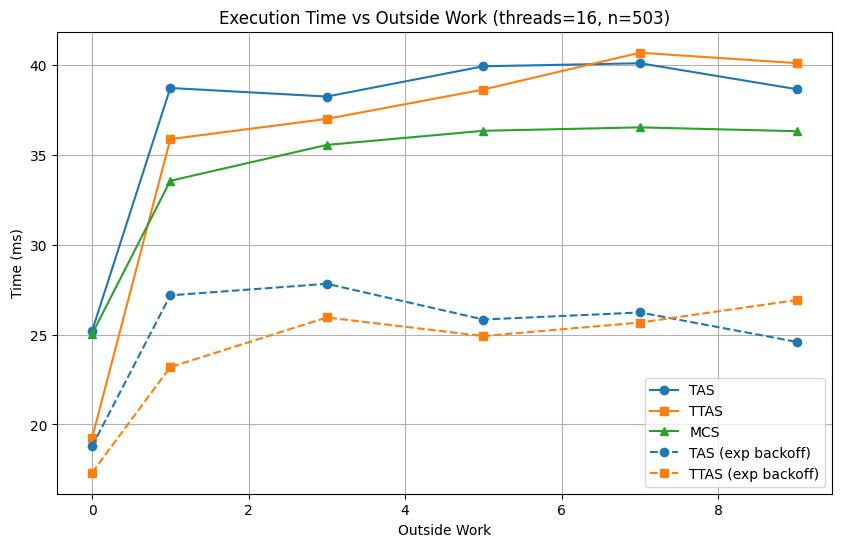

In [32]:
# Analyze contention: performance vs. outside_work at fixed thread count and n

fixed_threads = 16  # choose a representative thread count present in your data, e.g., 8
fixed_n = 503    # keep n same as above for consistency

# Group by thread count and compute mean execution time for each lock
df_contention = df[
    (df["threads"] == fixed_threads) &
    (df["n"] == fixed_n)
]
# df_contention = df


expbackoff_contention = df_with_exponential_backoff[
    (df_with_exponential_backoff["threads"] == fixed_threads) &
    (df_with_exponential_backoff["n"] == fixed_n)
]
# expbackoff_contention = df_with_exponential_backoff

##########

df_contention = df_contention.groupby("outside_work", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("outside_work")

plt.figure(figsize=(10, 6))
plt.plot(df_contention["outside_work"], df_contention["tas_ms"], marker='o', label="TAS")
plt.plot(df_contention["outside_work"], df_contention["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_contention["outside_work"], df_contention["mcs_ms"], marker='^', label="MCS")

# Also plot exp backoff variant for TAS and TTAS for comparison

expbackoff_contention = expbackoff_contention.groupby("outside_work", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("outside_work")

# Plot TAS exp backoff with same color/marker and dashed line
plt.plot(
    df_contention["outside_work"],
    expbackoff_contention["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)

# Plot TTAS exp backoff with same color/marker and dashed line
plt.plot(
    df_contention["outside_work"],
    expbackoff_contention["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)


plt.title(f"Execution Time vs Outside Work (threads={fixed_threads}, n={fixed_n})")
plt.xlabel("Outside Work")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Workload
- How the overall performance changes with different the critical section workload?

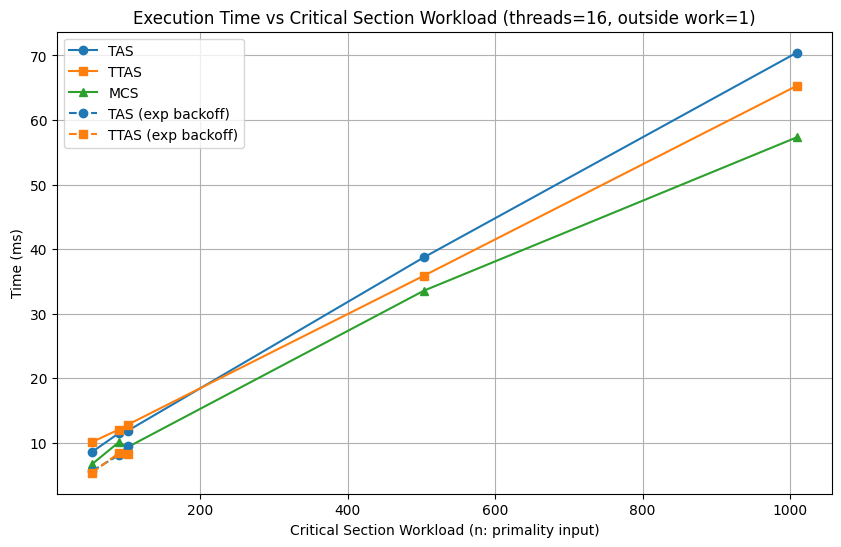

In [33]:
# Analyze workload: performance vs. n (the "critical section workload") at fixed thread count and outside_work

fixed_threads = 16  # keep consistent with earlier analysis
fixed_outside_work = 1  # minimal outside work to isolate impact of prime complexity

df_workload = df[
    (df["threads"] == fixed_threads) &
    (df["outside_work"] == fixed_outside_work) &
    (df["n"] <= 1009)
].groupby("n", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("n")

plt.figure(figsize=(10, 6))
plt.plot(df_workload["n"], df_workload["tas_ms"], marker='o', label="TAS")
plt.plot(df_workload["n"], df_workload["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_workload["n"], df_workload["mcs_ms"], marker='^', label="MCS")

# Plot exponential backoff results for workload as a dashed line with the same color mapping
expbackoff_workload = df_with_exponential_backoff[
    (df_with_exponential_backoff["threads"] == fixed_threads) &
    (df_with_exponential_backoff["outside_work"] == fixed_outside_work) &
    (df_with_exponential_backoff["n"] <= 101)
].groupby("n", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("n")

# Match colors to the existing TAS and TTAS lines
plt.plot(
    expbackoff_workload["n"],
    expbackoff_workload["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)
plt.plot(
    expbackoff_workload["n"],
    expbackoff_workload["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)


plt.title(f"Execution Time vs Critical Section Workload (threads={fixed_threads}, outside work={fixed_outside_work})")
plt.xlabel("Critical Section Workload (n: primality input)")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()